In [1]:
import os
import joblib
import numpy as np
import pandas as pd

def load_encoded(sample_size=10000):
    paths = [
        "data/processed/encoded.pkl",
        "../data/processed/encoded.pkl",
        "../../data/processed/encoded.pkl"
    ]

    df = None
    for path in paths:
        if os.path.exists(path):
            print(f"✅ Loading from: {path}")
            df = joblib.load(path)
            break

    if df is None:
        raise FileNotFoundError(
            "encoded.pkl not found.\nRun: python src/preprocessing/encoding.py"
        )

    # 🔥 Memory safe
    df = df.sample(n=min(sample_size, len(df)), random_state=42)

    return df

def ensure_numpy(X):
    return X.values if hasattr(X, "values") else X

In [2]:
df = load_encoded()

target = "defects"

X = df.drop(columns=[target])
y = df[target]

print("Feature shape:", X.shape)

✅ Loading from: ../data/processed/encoded.pkl
Feature shape: (10000, 37)


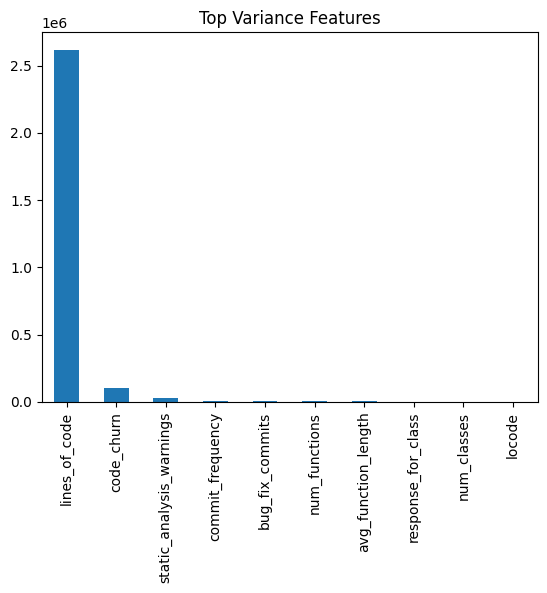

In [3]:
# Variance
import matplotlib.pyplot as plt

variance = X.var().sort_values(ascending=False)

variance.head(10).plot(kind="bar")
plt.title("Top Variance Features")
plt.show()

In [4]:
# Feature selection (safe)
from sklearn.feature_selection import SelectKBest, f_classif

k = min(50, X.shape[1])

selector = SelectKBest(f_classif, k=k)
X_new = selector.fit_transform(X, y)

print("Reduced shape:", X_new.shape)

Reduced shape: (10000, 37)
